In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcbG9pY2hcRG9jdW1lbnRzXFdvcmtcR2l0aHViXHF1YXJ0b1xweXRob25faWFfcXVhcnRvXG1vZHVsZXNcbW9kdWxlXzA1'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap_external.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\zipimport.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\codecs.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\aliases.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\__init__.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\utf_8.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\cp1252.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\abc.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python

In [2]:
#| label: setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
np.random.seed(42)

print("✅ Environnement prêt")

✅ Environnement prêt


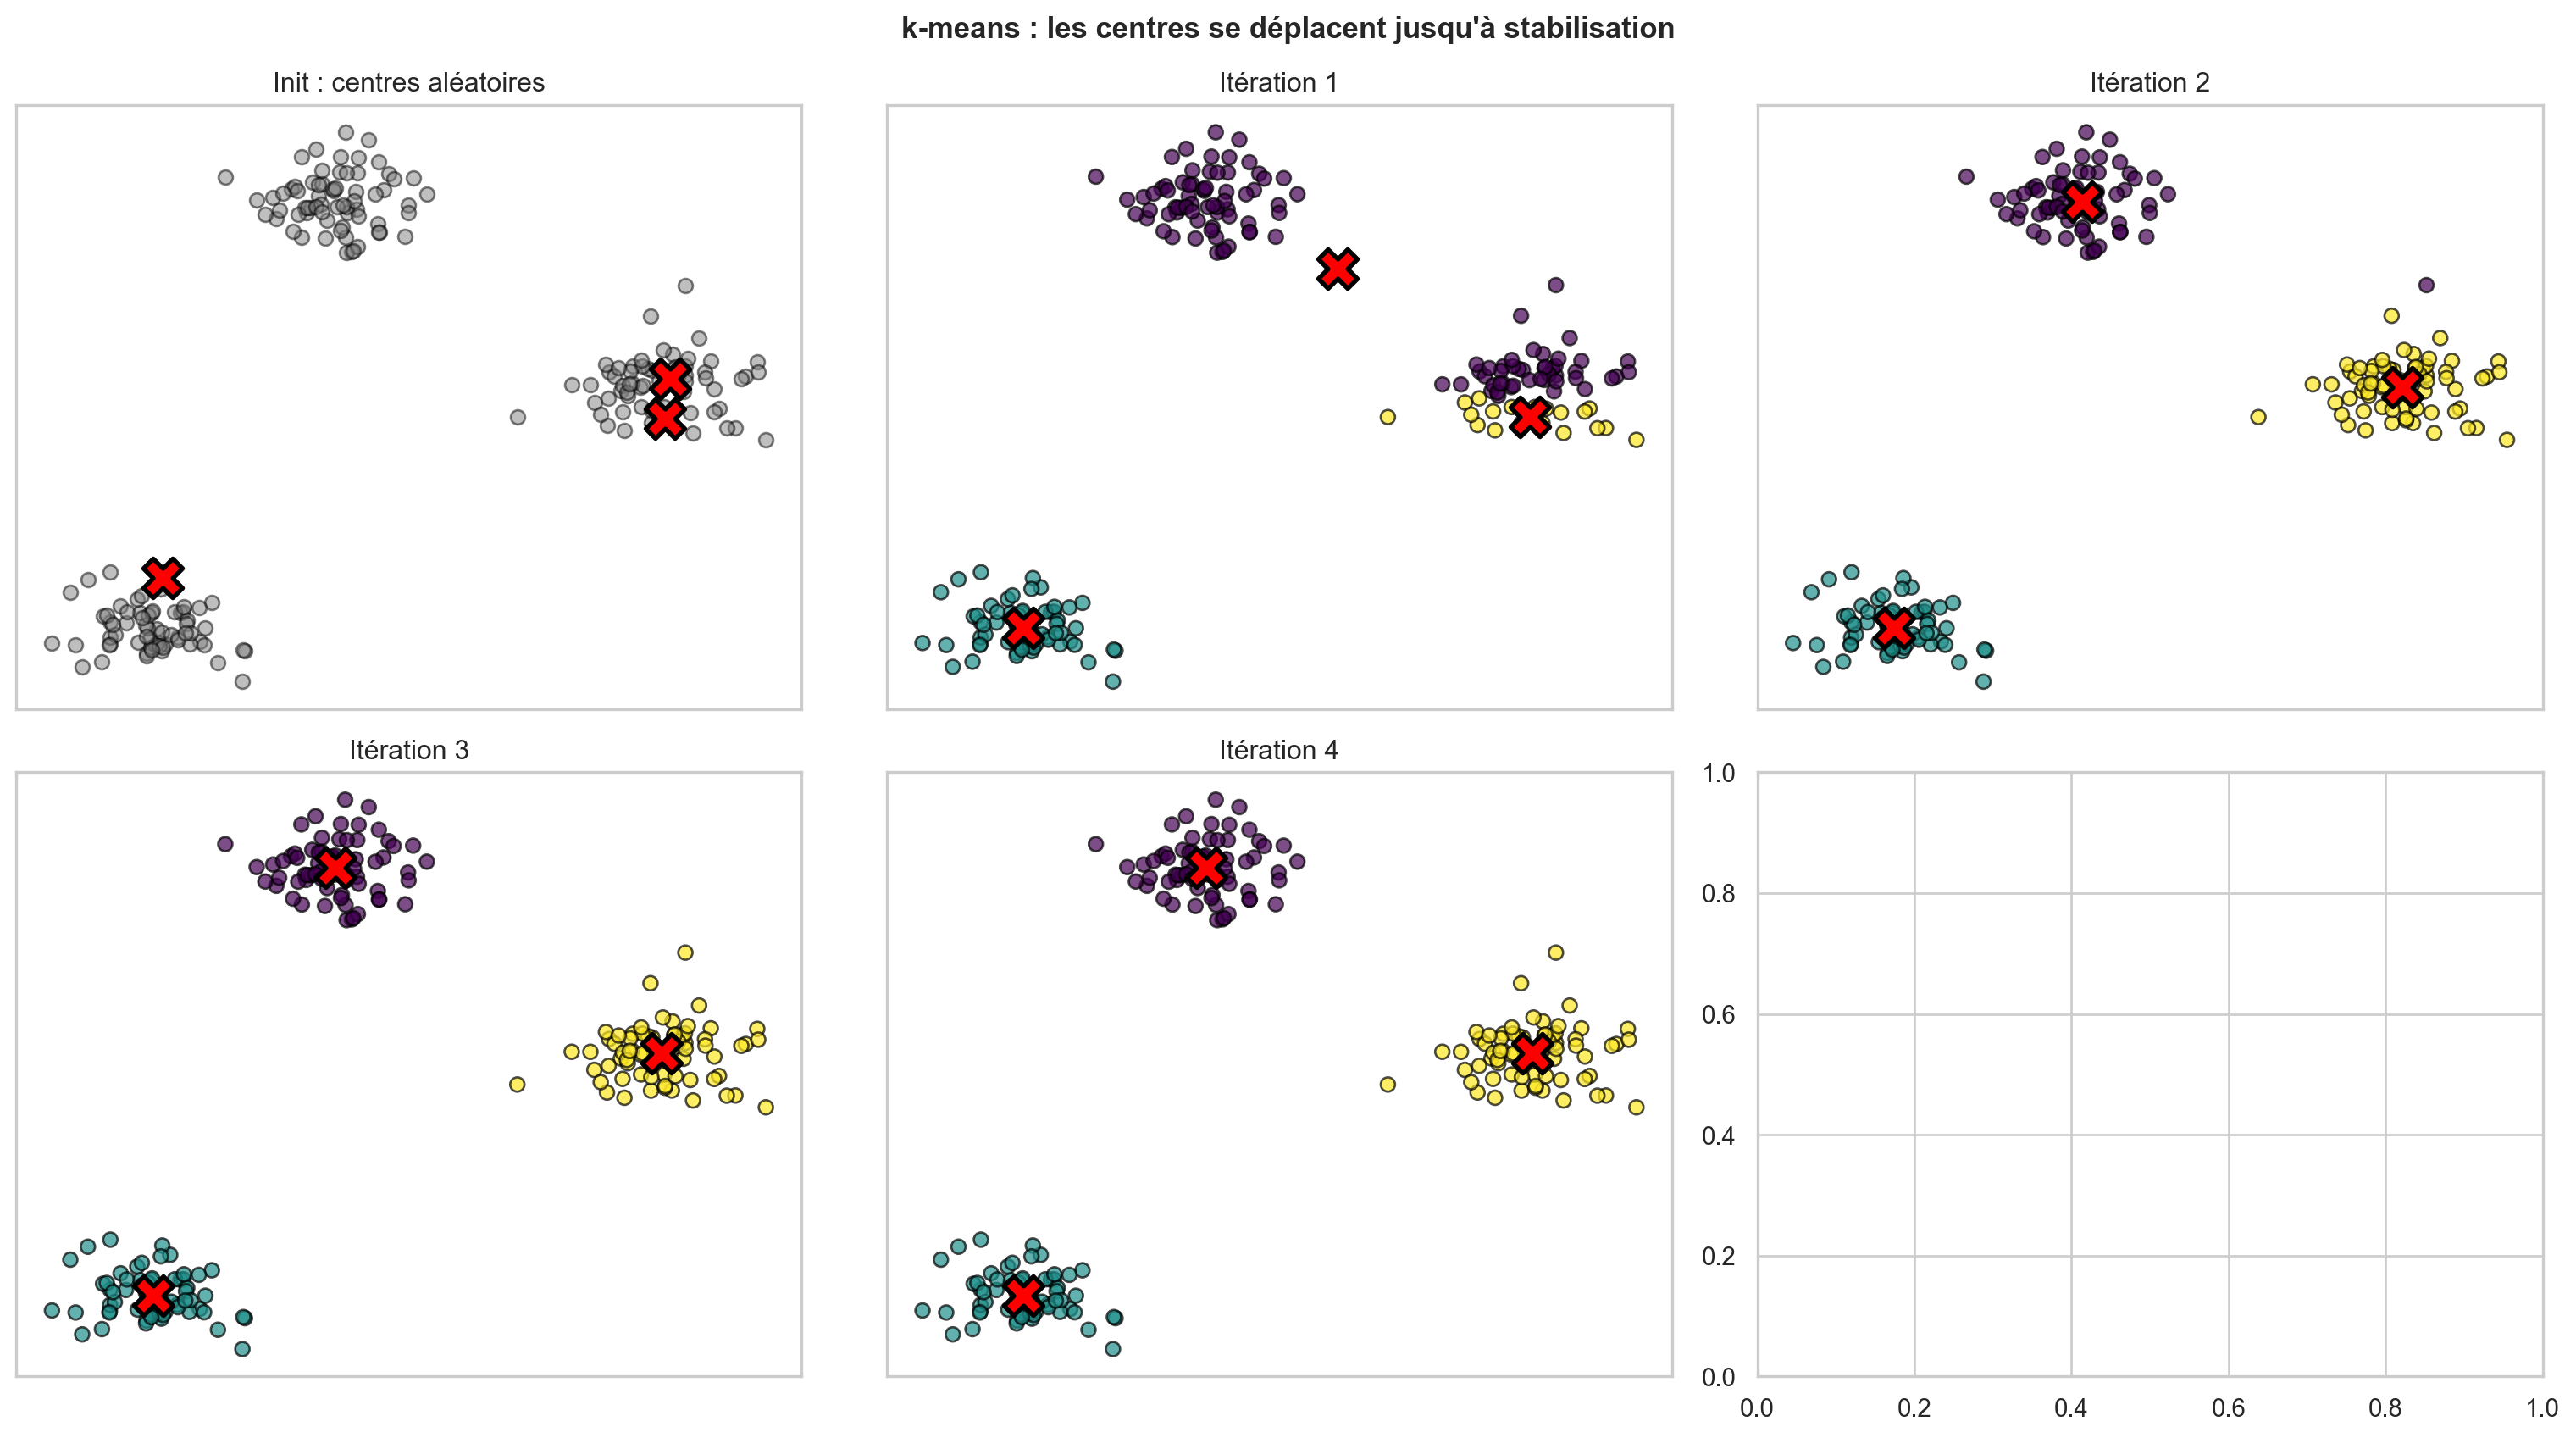

In [3]:
#| label: fig-kmeans-iterations
#| fig-cap: k-means itération par itération

# Générer des données
np.random.seed(42)
X, _ = make_blobs(n_samples=200, centers=3, cluster_std=1.0, random_state=42)

def kmeans_manuel(X, k, n_iter=5, seed=0):
    """Implémentation pédagogique de k-means avec historique."""
    rng = np.random.default_rng(seed)
    # Initialisation : k points aléatoires comme centres
    idx = rng.choice(len(X), k, replace=False)
    centres = X[idx].copy()
    
    historique = [(centres.copy(), None)]
    
    for it in range(n_iter):
        # Étape 2 : assignation
        distances = np.linalg.norm(X[:, None] - centres[None, :], axis=2)
        labels = distances.argmin(axis=1)
        
        # Étape 3 : mise à jour
        nouveaux_centres = np.array([X[labels == i].mean(axis=0) for i in range(k)])
        
        historique.append((nouveaux_centres.copy(), labels.copy()))
        
        # Convergence ?
        if np.allclose(centres, nouveaux_centres):
            break
        centres = nouveaux_centres
    
    return historique

# Faire tourner
historique = kmeans_manuel(X, k=3, n_iter=5, seed=7)

# Visualiser les itérations
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for i, (centres, labels) in enumerate(historique[:6]):
    ax = axes[i]
    if labels is None:
        ax.scatter(X[:, 0], X[:, 1], c="gray", s=40, alpha=0.5, edgecolor="black")
        ax.set_title(f"Init : centres aléatoires")
    else:
        ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=40, alpha=0.7, edgecolor="black")
        ax.set_title(f"Itération {i}")
    ax.scatter(centres[:, 0], centres[:, 1], marker="X", s=300, c="red", 
               edgecolor="black", linewidth=2, zorder=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("k-means : les centres se déplacent jusqu'à stabilisation", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
def mon_kmeans(X, k, max_iter=100, seed=0):
    """
    Implémentation éducative de k-means.
    
    Retourne les labels de cluster et les centres.
    """
    rng = np.random.default_rng(seed)
    
    # 1. Initialisation : k points au hasard
    idx_init = rng.choice(len(X), k, replace=False)
    centres = X[idx_init].copy()
    
    for it in range(max_iter):
        # 2. Assignation : chaque point au centre le plus proche
        # Broadcasting : (n, 1, d) - (1, k, d) → (n, k, d) → (n, k)
        distances = np.linalg.norm(X[:, None, :] - centres[None, :, :], axis=2)
        labels = distances.argmin(axis=1)
        
        # 3. Mise à jour : centre = moyenne des points du cluster
        nouveaux_centres = np.array([
            X[labels == i].mean(axis=0) if (labels == i).any() else centres[i]
            for i in range(k)
        ])
        
        # 4. Test de convergence
        if np.allclose(centres, nouveaux_centres):
            print(f"Convergence atteinte en {it + 1} itérations")
            break
        centres = nouveaux_centres
    
    return labels, centres

In [5]:
# Sur les blobs précédents
labels_manuel, centres_manuel = mon_kmeans(X, k=3, seed=42)

# Inertie calculée à la main
distances_min = np.linalg.norm(X - centres_manuel[labels_manuel], axis=1)
inertie_manuel = (distances_min ** 2).sum()
print(f"Inertie (from scratch) : {inertie_manuel:.2f}")

# Comparer à sklearn
kmeans_sklearn = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X)
print(f"Inertie (sklearn)      : {kmeans_sklearn.inertia_:.2f}")

Convergence atteinte en 3 itérations
Inertie (from scratch) : 364.47


Inertie (sklearn)      : 364.47


In [6]:
#| eval: false
# TODO: Exercice 1

In [7]:
inerties = []
for seed in range(5):
    labels, centres = mon_kmeans(X, k=3, seed=seed)
    distances_min = np.linalg.norm(X - centres[labels], axis=1)
    inertie = (distances_min ** 2).sum()
    inerties.append(inertie)
    print(f"Seed {seed} : inertie = {inertie:.2f}")

print(f"\nMin : {min(inerties):.2f}")
print(f"Max : {max(inerties):.2f}")
print(f"Écart : {max(inerties) - min(inerties):.2f}")

Convergence atteinte en 3 itérations
Seed 0 : inertie = 364.47
Convergence atteinte en 7 itérations
Seed 1 : inertie = 3682.99
Convergence atteinte en 3 itérations
Seed 2 : inertie = 364.47
Convergence atteinte en 3 itérations
Seed 3 : inertie = 364.47
Convergence atteinte en 3 itérations
Seed 4 : inertie = 364.47

Min : 364.47
Max : 3682.99
Écart : 3318.52


In [8]:
# k-means++ est implicite :
kmeans = KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=42)
# "k-means++" est le défaut, on peut l'omettre

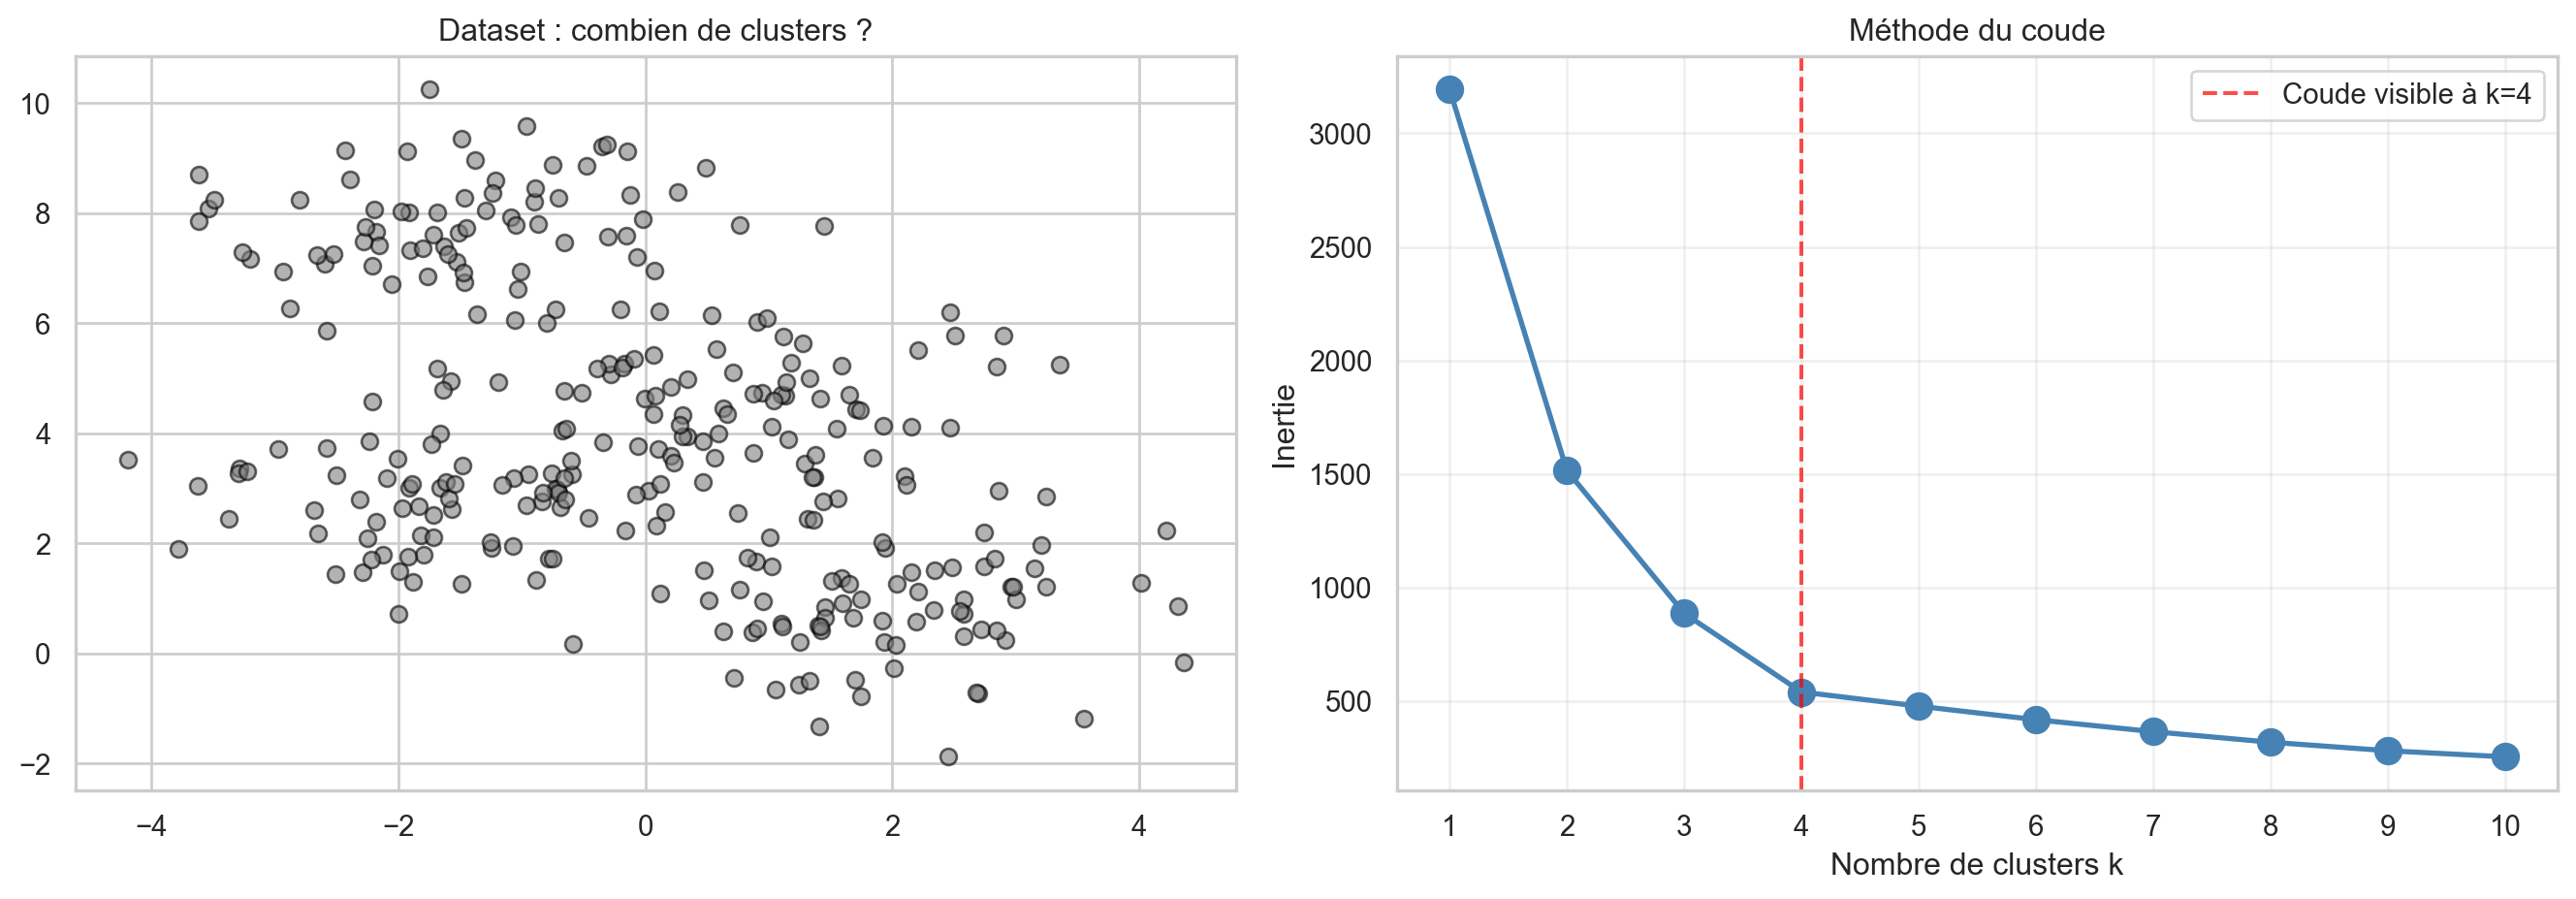

In [9]:
#| label: fig-elbow
#| fig-cap: Méthode du coude pour choisir k

# Dataset avec 4 vrais clusters
np.random.seed(0)
X_elbow, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=0)

# Calculer l'inertie pour k de 1 à 10
inerties = []
k_values = range(1, 11)
for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=0)
    km.fit(X_elbow)
    inerties.append(km.inertia_)

# Tracer
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Données
axes[0].scatter(X_elbow[:, 0], X_elbow[:, 1], c="gray", s=40, alpha=0.6, edgecolor="black")
axes[0].set_title("Dataset : combien de clusters ?")

# Courbe de l'inertie
axes[1].plot(k_values, inerties, "o-", linewidth=2, markersize=10, color="steelblue")
axes[1].axvline(4, color="red", linestyle="--", alpha=0.7, label="Coude visible à k=4")
axes[1].set_xlabel("Nombre de clusters k")
axes[1].set_ylabel("Inertie")
axes[1].set_title("Méthode du coude")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(k_values)

plt.tight_layout()
plt.show()

In [10]:
# Sur notre dataset blobs
silhouettes = []
for k in range(2, 11):  # silhouette pas défini pour k=1
    km = KMeans(n_clusters=k, n_init=10, random_state=0)
    labels = km.fit_predict(X_elbow)
    s = silhouette_score(X_elbow, labels)
    silhouettes.append(s)

# DataFrame récap
df_sil = pd.DataFrame({
    "k": range(2, 11),
    "silhouette": silhouettes
})
print(df_sil.round(3).to_string(index=False))

 k  silhouette
 2       0.448
 3       0.457
 4       0.501
 5       0.453
 6       0.412
 7       0.381
 8       0.345
 9       0.351
10       0.365


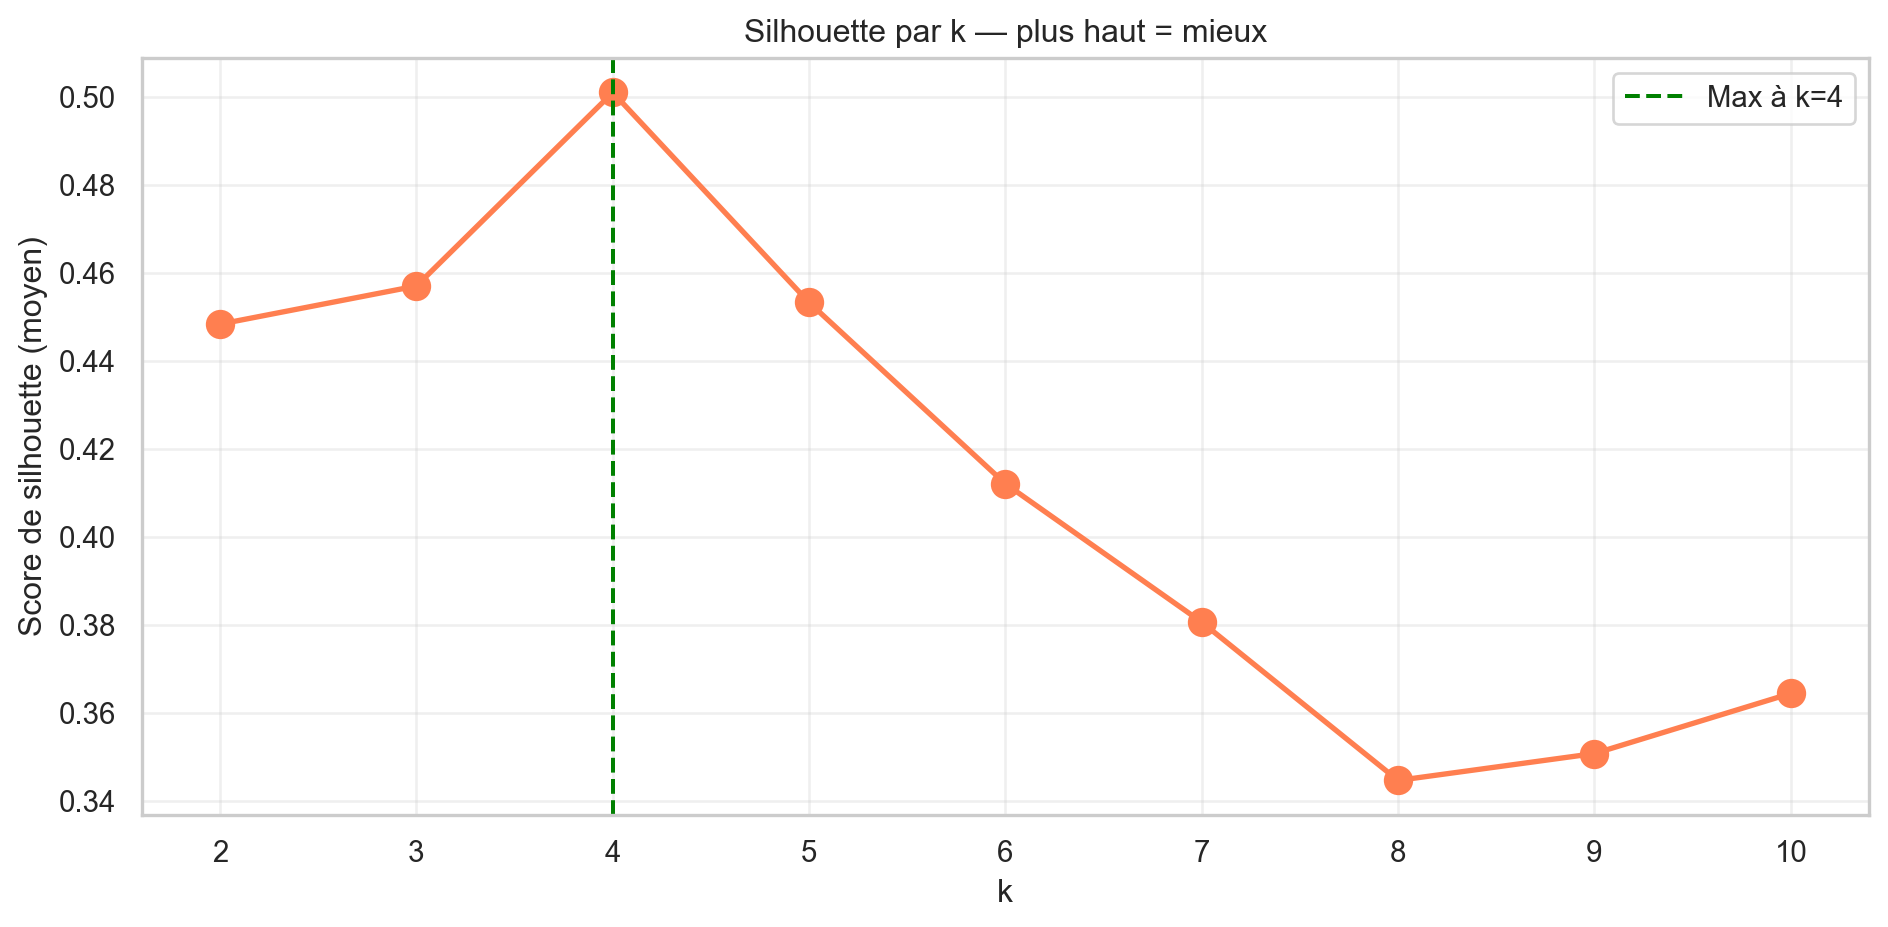

In [11]:
#| label: fig-silhouette-score
#| fig-cap: Score de silhouette en fonction de k

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(2, 11), silhouettes, "o-", linewidth=2, markersize=10, color="coral")
k_optimal = range(2, 11)[np.argmax(silhouettes)]
ax.axvline(k_optimal, color="green", linestyle="--", label=f"Max à k={k_optimal}")
ax.set_xlabel("k")
ax.set_ylabel("Score de silhouette (moyen)")
ax.set_title("Silhouette par k — plus haut = mieux")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

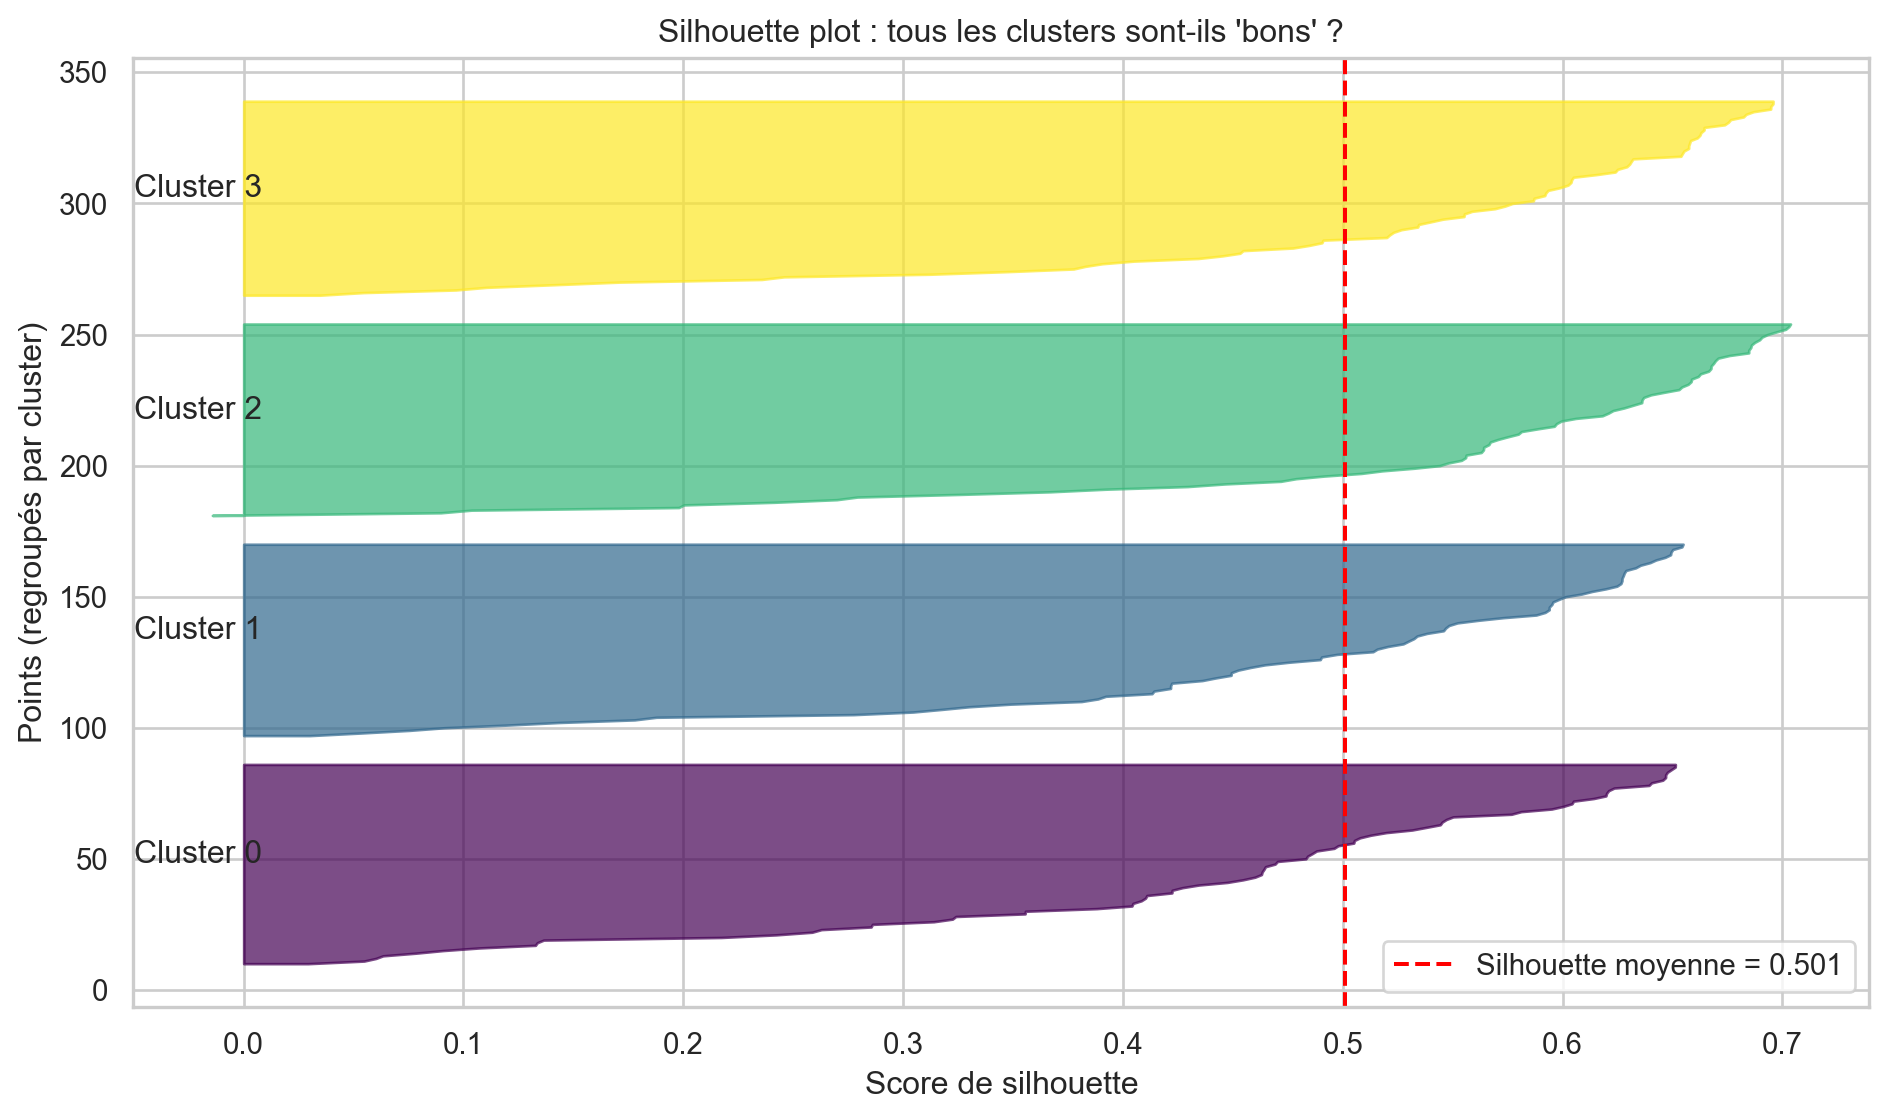

In [12]:
#| label: fig-silhouette-plot
#| fig-cap: Silhouette plot pour k=4

km = KMeans(n_clusters=4, n_init=10, random_state=0)
labels = km.fit_predict(X_elbow)
sil_samples = silhouette_samples(X_elbow, labels)
sil_avg = silhouette_score(X_elbow, labels)

fig, ax = plt.subplots(figsize=(10, 6))

y_lower = 10
colors = plt.cm.viridis(np.linspace(0, 1, 4))

for i in range(4):
    cluster_sils = sil_samples[labels == i]
    cluster_sils.sort()
    
    size_cluster_i = cluster_sils.shape[0]
    y_upper = y_lower + size_cluster_i
    
    ax.fill_betweenx(
        np.arange(y_lower, y_upper), 0, cluster_sils,
        facecolor=colors[i], edgecolor=colors[i], alpha=0.7
    )
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, f"Cluster {i}")
    y_lower = y_upper + 10

ax.axvline(sil_avg, color="red", linestyle="--", label=f"Silhouette moyenne = {sil_avg:.3f}")
ax.set_xlabel("Score de silhouette")
ax.set_ylabel("Points (regroupés par cluster)")
ax.set_title("Silhouette plot : tous les clusters sont-ils 'bons' ?")
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
#| eval: false
# TODO: Exercice 2

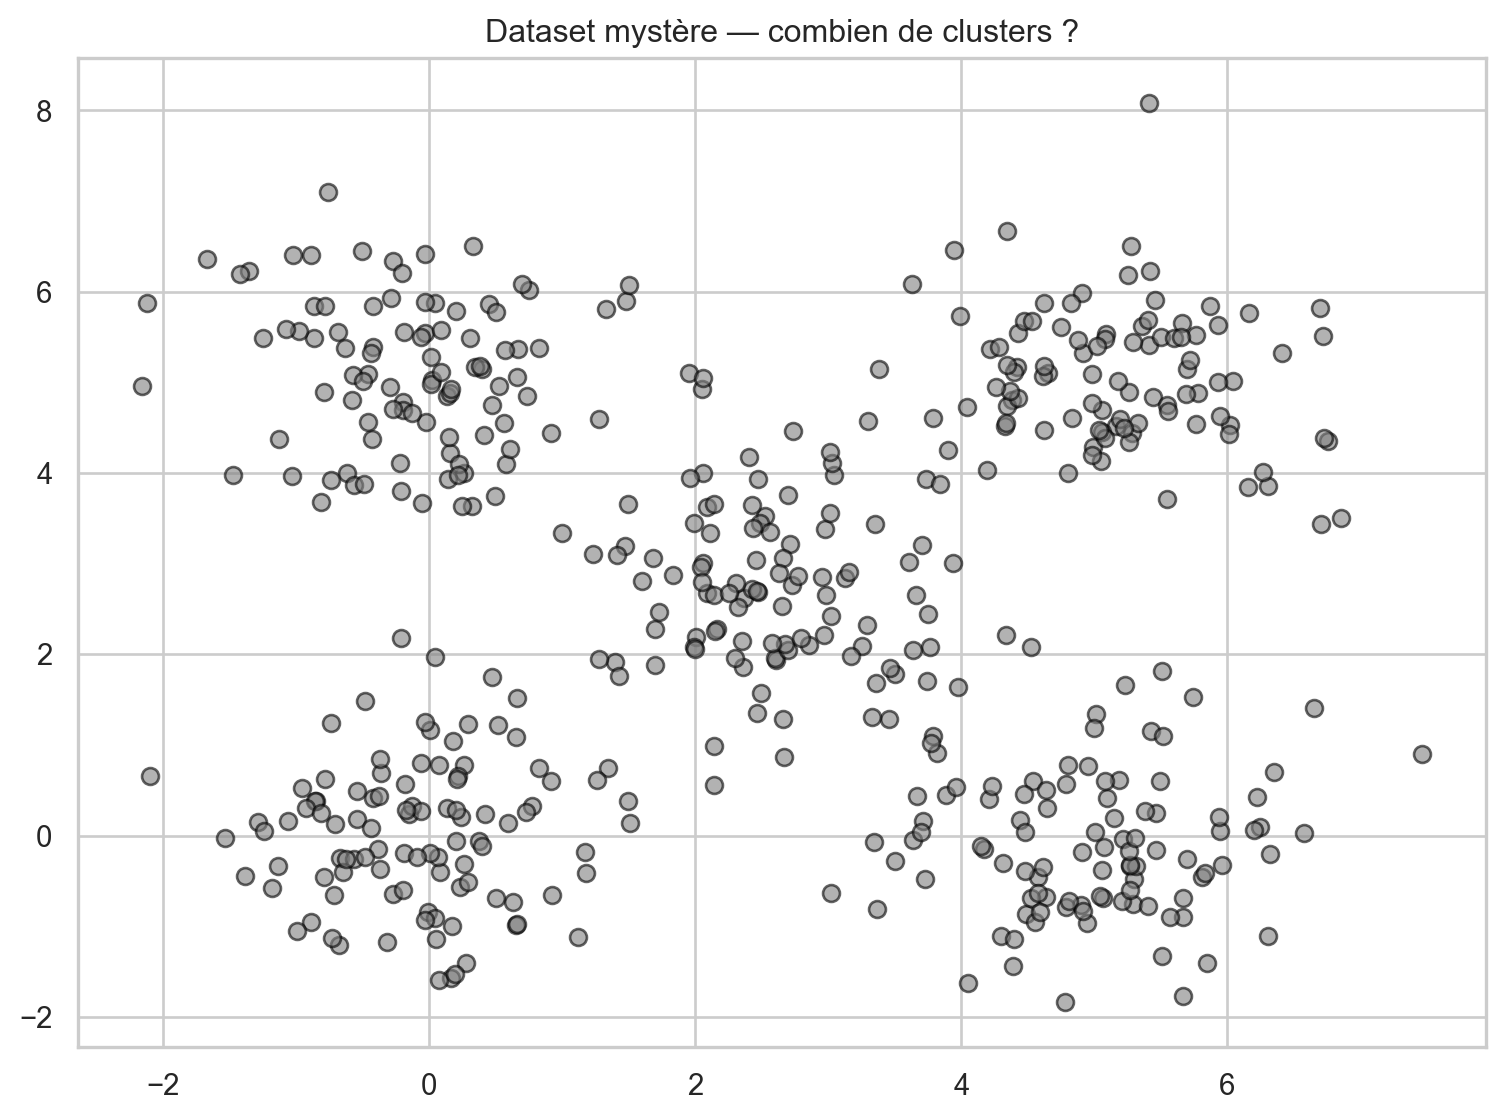

In [14]:
X_mystere, vrais_labels = make_blobs(
    n_samples=500, 
    centers=[[0, 0], [5, 5], [5, 0], [0, 5], [2.5, 2.5]],
    cluster_std=0.8, random_state=42
)

# 1. Visualiser
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_mystere[:, 0], X_mystere[:, 1], c="gray", s=40, alpha=0.6, edgecolor="black")
ax.set_title("Dataset mystère — combien de clusters ?")
plt.tight_layout()
plt.show()

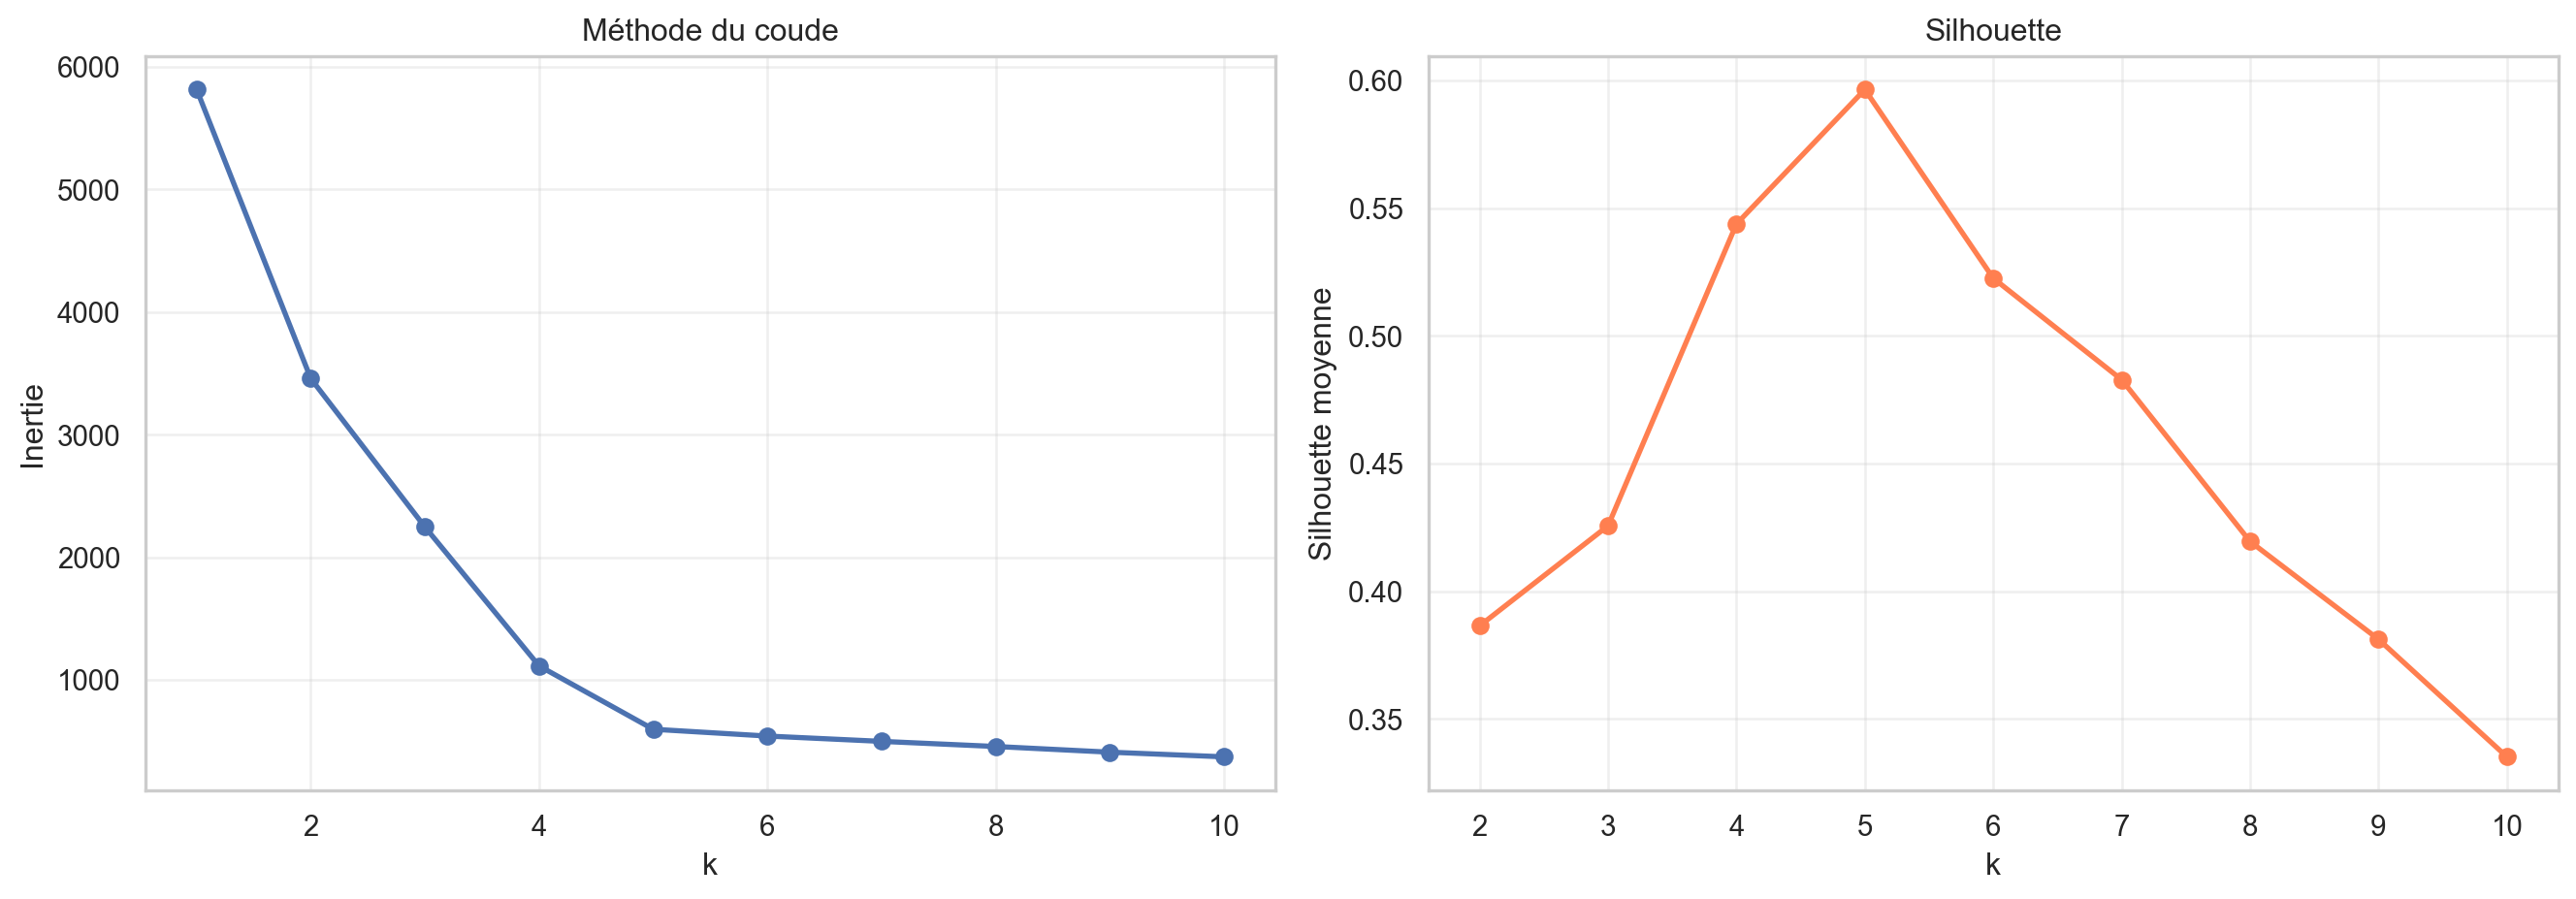

In [15]:
# 2 et 3. Courbes
inerties = []
silhouettes = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_mystere)
    inerties.append(km.inertia_)
    if k > 1:
        silhouettes.append(silhouette_score(X_mystere, labels))
    else:
        silhouettes.append(np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, 11), inerties, "o-", linewidth=2)
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertie")
axes[0].set_title("Méthode du coude")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(2, 11), silhouettes[1:], "o-", linewidth=2, color="coral")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette moyenne")
axes[1].set_title("Silhouette")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

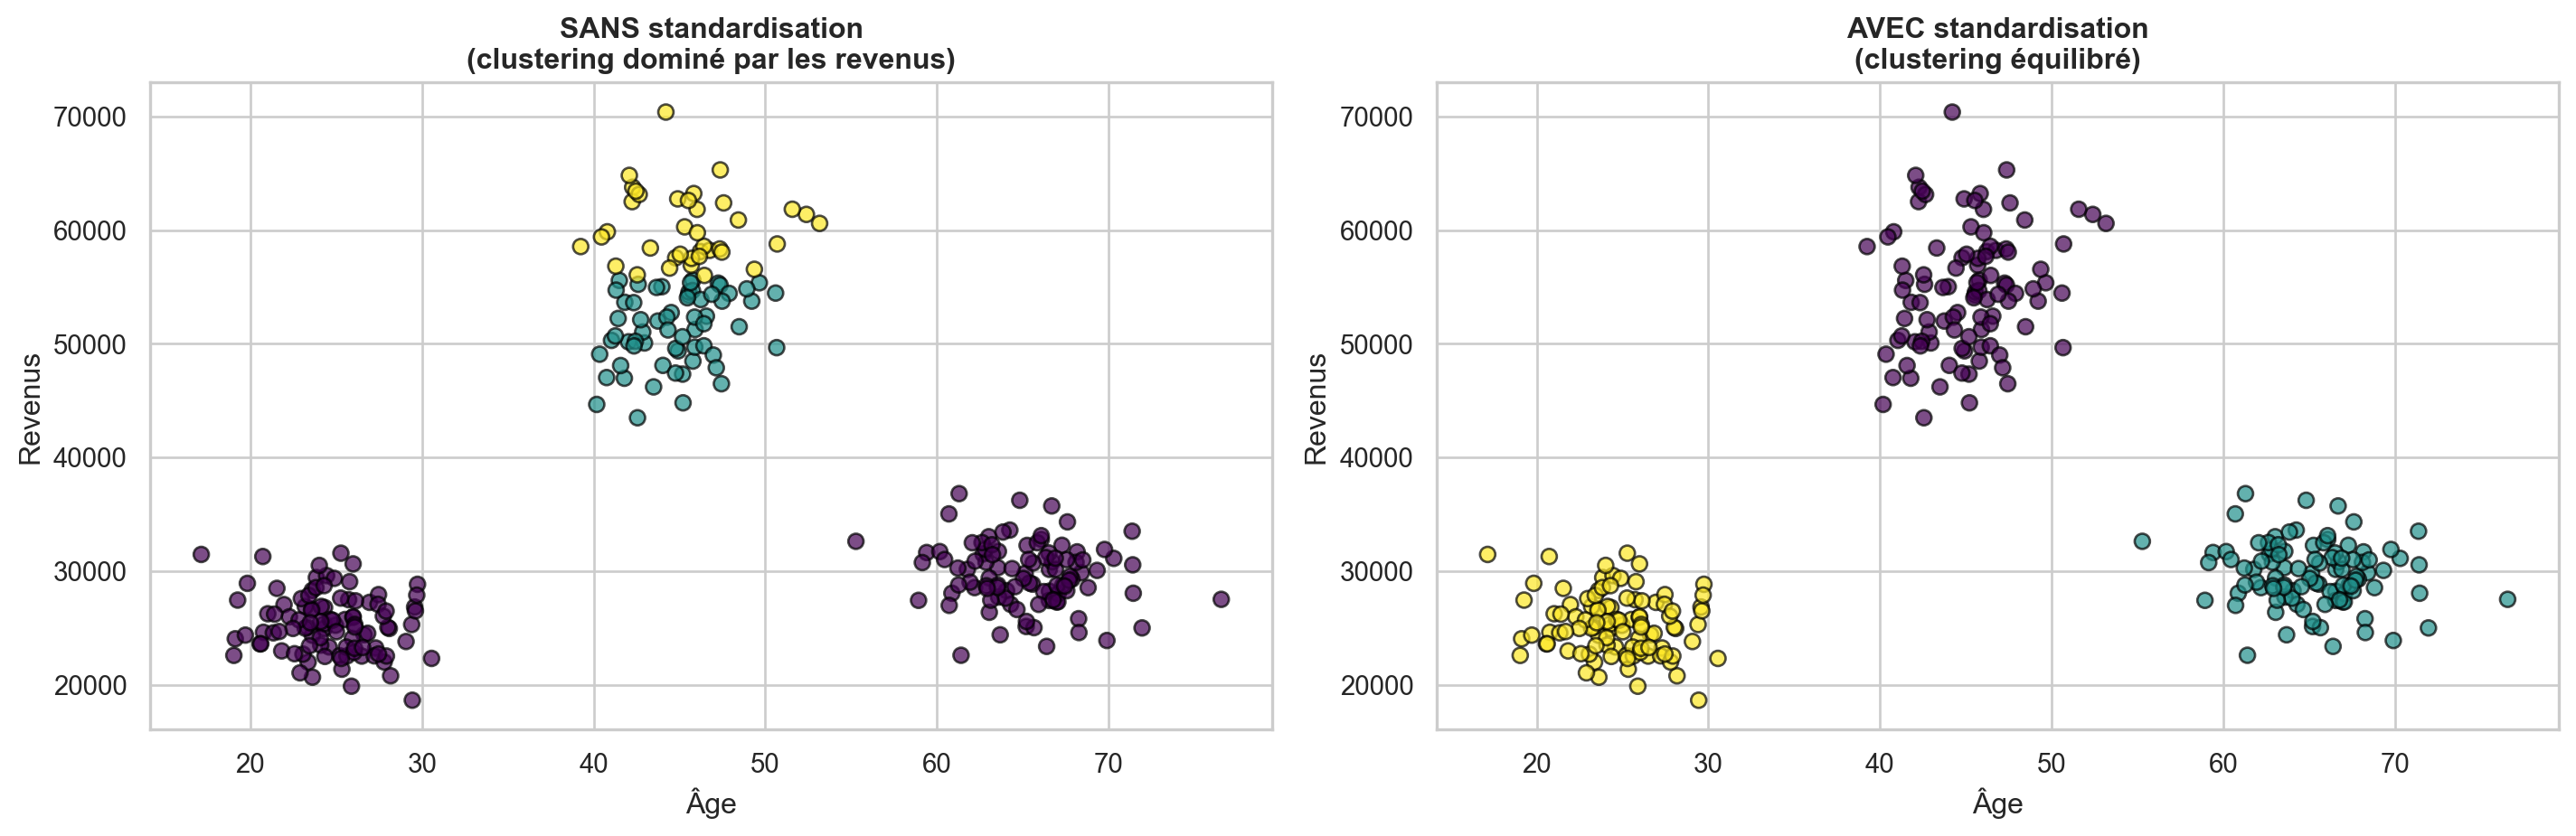

In [16]:
# Créer un dataset avec des échelles très différentes
np.random.seed(42)
n = 300
df_clients = pd.DataFrame({
    "age": np.concatenate([
        np.random.normal(25, 3, 100),     # jeunes
        np.random.normal(45, 3, 100),     # actifs
        np.random.normal(65, 3, 100),     # retraités
    ]),
    "revenus": np.concatenate([
        np.random.normal(25000, 3000, 100),   # jeunes
        np.random.normal(55000, 5000, 100),   # actifs
        np.random.normal(30000, 3000, 100),   # retraités
    ])
})

# 3 vrais groupes par âge : jeunes, actifs, retraités

X_clients = df_clients.values

# k-means SANS standardisation
km_brut = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_brut = km_brut.fit_predict(X_clients)

# k-means AVEC standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clients)
km_scaled = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_scaled = km_scaled.fit_predict(X_scaled)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(df_clients["age"], df_clients["revenus"], c=labels_brut, 
                cmap="viridis", s=40, alpha=0.7, edgecolor="black")
axes[0].set_title("SANS standardisation\n(clustering dominé par les revenus)", fontweight="bold")
axes[0].set_xlabel("Âge"); axes[0].set_ylabel("Revenus")

axes[1].scatter(df_clients["age"], df_clients["revenus"], c=labels_scaled,
                cmap="viridis", s=40, alpha=0.7, edgecolor="black")
axes[1].set_title("AVEC standardisation\n(clustering équilibré)", fontweight="bold")
axes[1].set_xlabel("Âge"); axes[1].set_ylabel("Revenus")

plt.tight_layout()
plt.show()

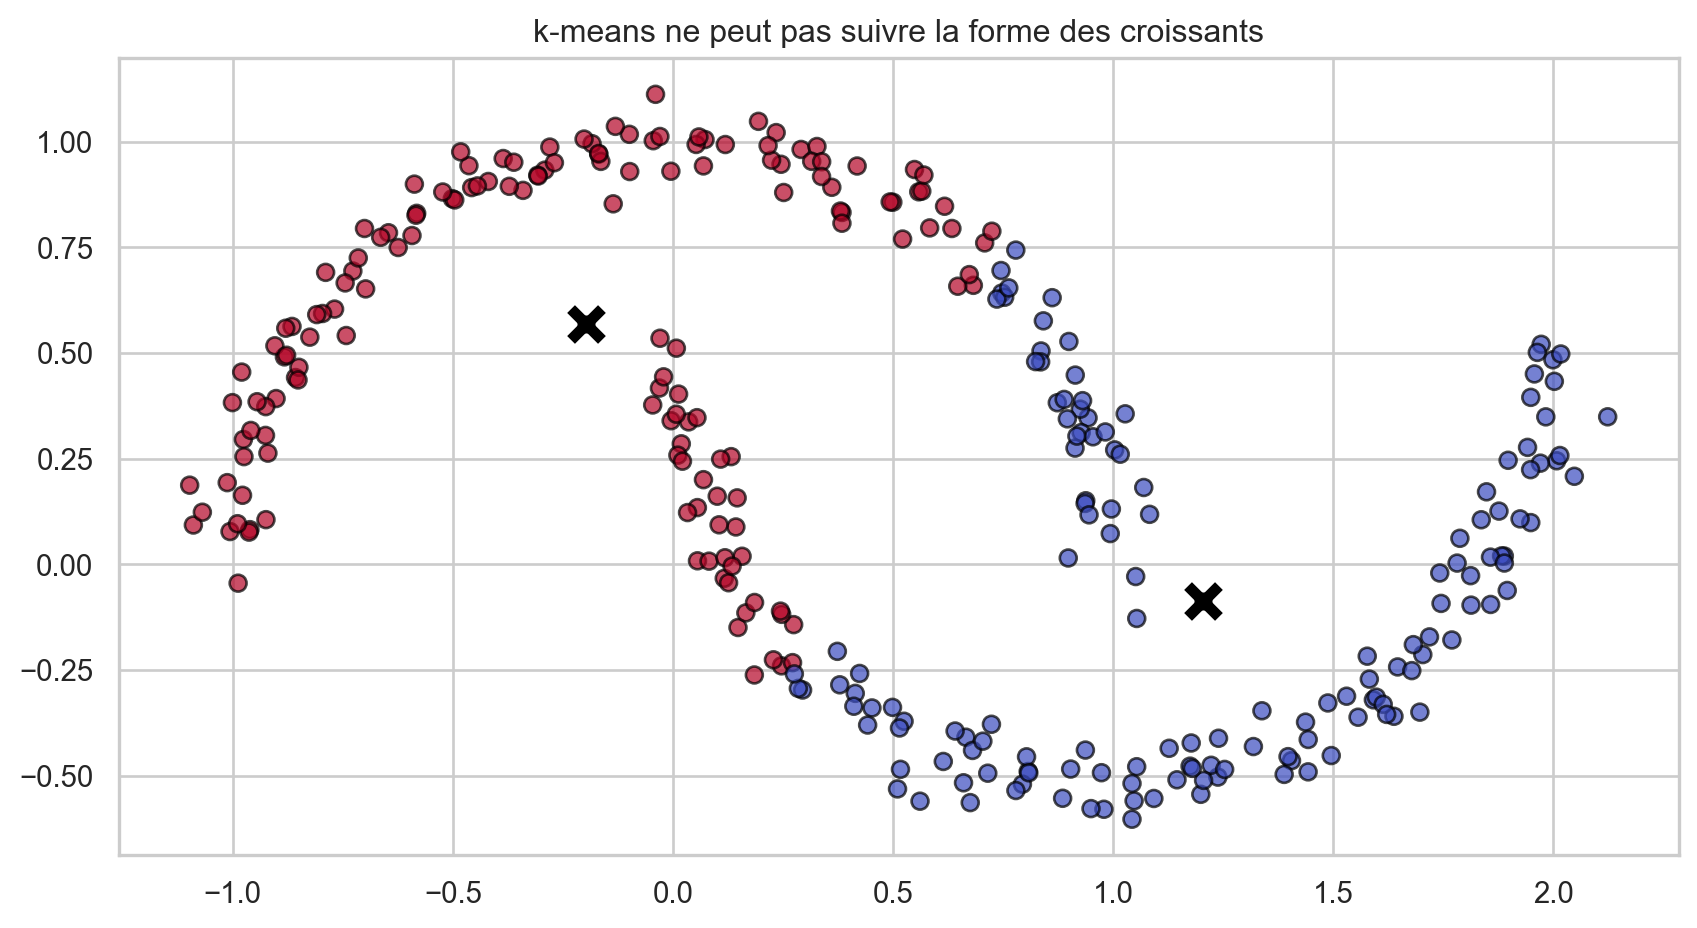

In [17]:
#| label: fig-moons-fail
#| fig-cap: k-means rate les clusters non-convexes

X_moons, _ = make_moons(n_samples=300, noise=0.05, random_state=0)
km = KMeans(n_clusters=2, n_init=10, random_state=0)
labels = km.fit_predict(X_moons)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X_moons[:, 0], X_moons[:, 1], c=labels, cmap="coolwarm", s=40, alpha=0.7, edgecolor="black")
ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
           marker="X", s=300, c="black", edgecolor="white", linewidth=2)
ax.set_title("k-means ne peut pas suivre la forme des croissants")
plt.tight_layout()
plt.show()

In [18]:
#| eval: false
# TODO: Exercice bilan

In [19]:
np.random.seed(42)
n = 600

df = pd.DataFrame({
    "frequence_achats_an": np.concatenate([
        np.random.gamma(8, 1, 200),
        np.random.gamma(3, 1, 250),
        np.random.gamma(1, 1, 150),
    ]),
    "panier_moyen_eur": np.concatenate([
        np.random.normal(45, 15, 200),
        np.random.normal(80, 25, 250),
        np.random.normal(30, 10, 150),
    ]),
    "anciennete_mois": np.concatenate([
        np.random.uniform(12, 60, 200),
        np.random.uniform(6, 36, 250),
        np.random.uniform(0, 24, 150),
    ]),
})
df["panier_moyen_eur"] = df["panier_moyen_eur"].clip(lower=5)
df["frequence_achats_an"] = df["frequence_achats_an"].clip(lower=0.1)

# 1. Stats
print(df.describe().round(2))

       frequence_achats_an  panier_moyen_eur  anciennete_mois
count               600.00            600.00           600.00
mean                  4.22             57.28            23.78
std                   3.49             28.60            13.87
min                   0.10              5.00             0.21
25%                   1.45             35.76            13.66
50%                   3.10             50.96            21.47
75%                   6.58             76.85            31.81
max                  24.05            144.49            59.92


In [20]:
# 2. Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

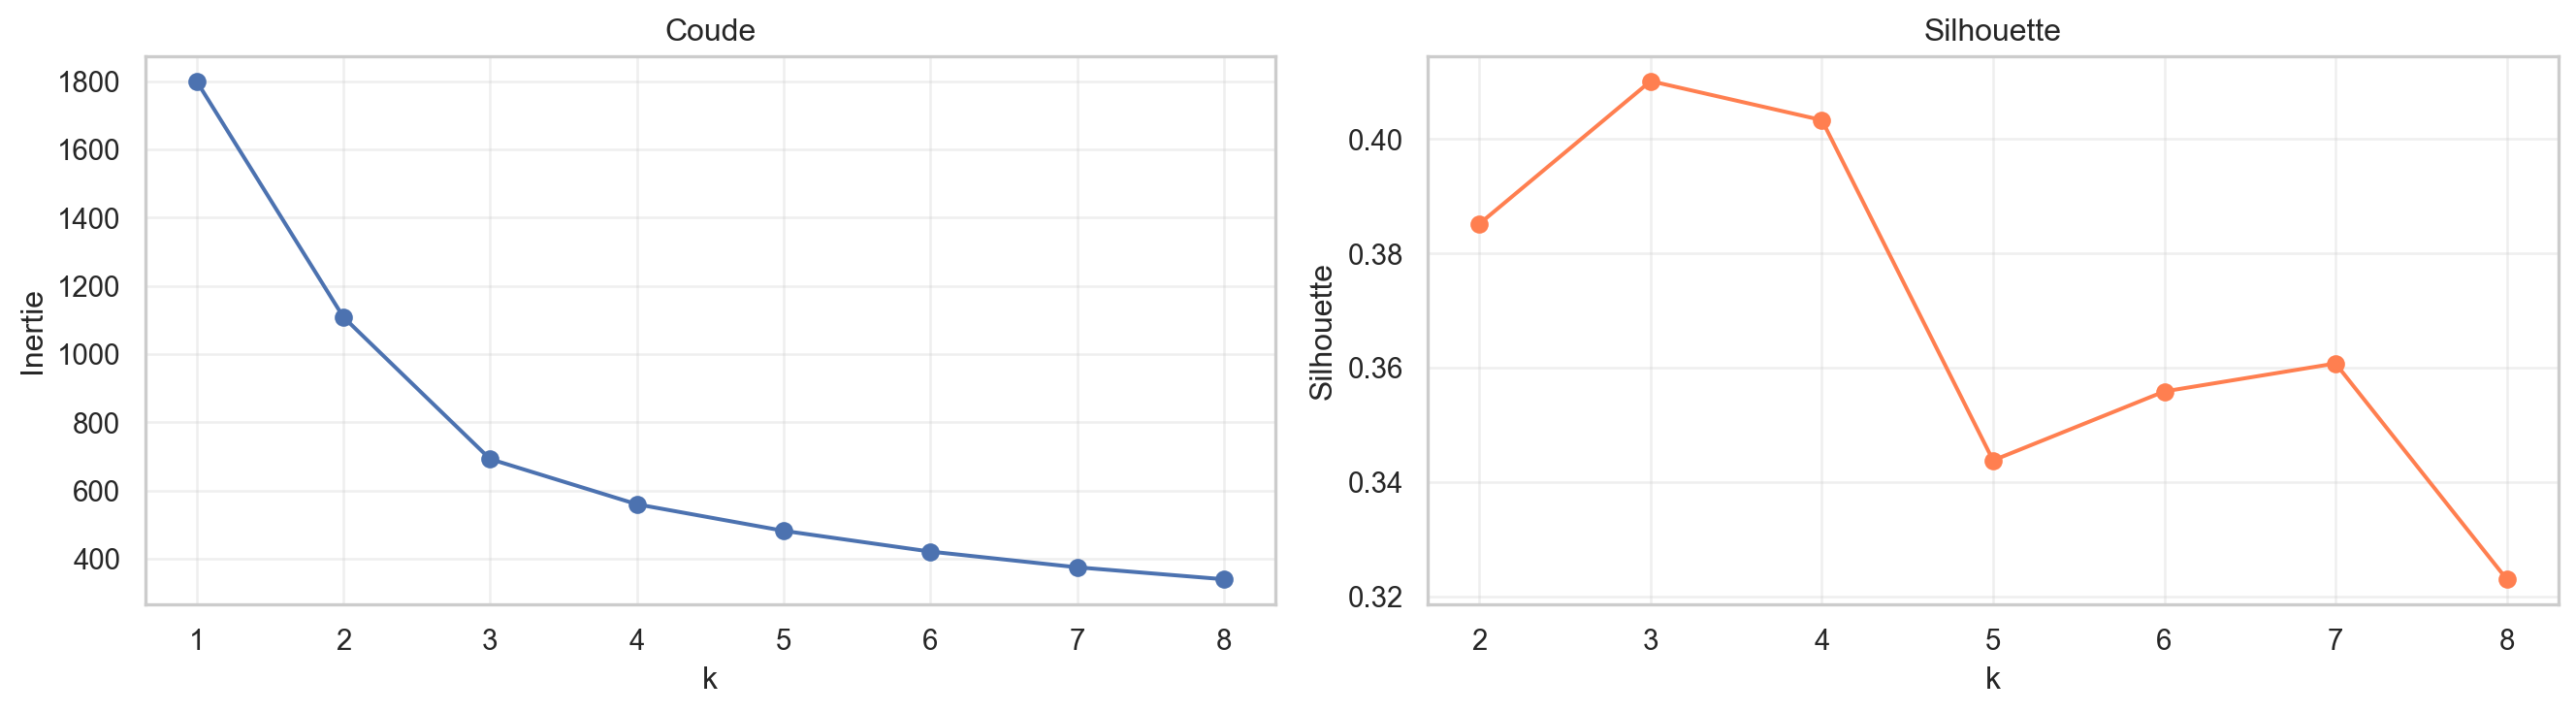

k optimal selon silhouette : 3


In [21]:
# 3. Coude + silhouette
inerties = []
silhouettes = []
for k in range(1, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inerties.append(km.inertia_)
    if k > 1:
        silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(range(1, 9), inerties, "o-")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertie")
axes[0].set_title("Coude"); axes[0].grid(True, alpha=0.3)

axes[1].plot(range(2, 9), silhouettes, "o-", color="coral")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
axes[1].set_title("Silhouette"); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

k_optimal = np.argmax(silhouettes) + 2  # +2 car silhouettes commence à k=2
print(f"k optimal selon silhouette : {k_optimal}")

In [22]:
# 4. Clustering final
km_final = KMeans(n_clusters=k_optimal, n_init=10, random_state=42)
df["cluster"] = km_final.fit_predict(X_scaled)

print(f"Nombre de clients par cluster :")
print(df["cluster"].value_counts().sort_index())

Nombre de clients par cluster :
cluster
0    204
1    180
2    216
Name: count, dtype: int64


In [23]:
# 5. Profil de chaque cluster
profils = df.groupby("cluster").agg({
    "frequence_achats_an": "mean",
    "panier_moyen_eur": "mean",
    "anciennete_mois": "mean",
}).round(1)

profils["n_clients"] = df["cluster"].value_counts().sort_index().values
print("\nProfil moyen par cluster :")
print(profils)


Profil moyen par cluster :
         frequence_achats_an  panier_moyen_eur  anciennete_mois  n_clients
cluster                                                                   
0                        3.0              90.0             21.0        204
1                        8.4              46.7             38.4        180
2                        1.9              35.2             14.2        216


In [24]:
# 6-7. Nommer et actions (à adapter selon tes clusters)
print("\n=== PROPOSITIONS MARKETING ===")
for c in sorted(df["cluster"].unique()):
    profil = profils.loc[c]
    print(f"\nCluster {c} ({profil['n_clients']:.0f} clients) :")
    print(f"  Fréquence : {profil['frequence_achats_an']} achats/an")
    print(f"  Panier moyen : {profil['panier_moyen_eur']} €")
    print(f"  Ancienneté : {profil['anciennete_mois']} mois")

# Exemple générique :
print("\n\nActions marketing à adapter :")
print("- Très actifs + gros panier → programme VIP, avant-premières")
print("- Moyens actifs → upsell, recommandations personnalisées")
print("- Inactifs / nouveaux → campagnes de réactivation, offres de bienvenue")


=== PROPOSITIONS MARKETING ===

Cluster 0 (204 clients) :
  Fréquence : 3.0 achats/an
  Panier moyen : 90.0 €
  Ancienneté : 21.0 mois

Cluster 1 (180 clients) :
  Fréquence : 8.4 achats/an
  Panier moyen : 46.7 €
  Ancienneté : 38.4 mois

Cluster 2 (216 clients) :
  Fréquence : 1.9 achats/an
  Panier moyen : 35.2 €
  Ancienneté : 14.2 mois


Actions marketing à adapter :
- Très actifs + gros panier → programme VIP, avant-premières
- Moyens actifs → upsell, recommandations personnalisées
- Inactifs / nouveaux → campagnes de réactivation, offres de bienvenue
